# Christian Chung - BIOE242 Project Checkpoint 1: Data Preparation

## Dataset overview
| Suite | Variants | Parameter swept | Snapshots/variant |
|-------|----------|-----------------|-------------------|
| Adhesion | 10 | Line tension (0.00-2.00) | ~84-119 |
| DeformationEnergy | 10 | Area elasticity (1.0-50.0) | ~91-600 |
| Proliferation | 10 | Cell-cycle scale (0.10-2.00) | ~22-199 |
| Control (Motility) | 1 | N/A | 110 |

## Graph representation
- **Node** = one epithelial cell  
- **Edge** = shared cell-cell interface (undirected)  
- **Node features** `x`: `[area, perimeter, shape_index, n_neighbors]`  
- **Edge features** `edge_attr`: `[shared_edge_length]`  
- **Graph label** `y`: `[sim_type_int, param_value_normalized]`  

## Split strategy
Split **by simulation variant** (not by frame) to prevent temporal autocorrelation.  
Within each suite: 7 train / 2 val / 1 test variants.  All frames from a variant go into one split.

## 1. Imports and configuration

In [1]:
import os
import re
import glob
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import meshio

import torch
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

warnings.filterwarnings('ignore')

# Paths 
ROOT = Path(r'c:/Users/cmchu/OneDrive/Desktop/Gu Lab/BIOE242 Data')
SIM_ROOT = ROOT / 'replicated_testoutput' / 'EpithelialRheology'
BANK = ROOT / 'BIOE242 Data Bank Complete'
BANK.mkdir(exist_ok=True)

print(f'Simulation root : {SIM_ROOT}')
print(f'Data bank       : {BANK}')

Simulation root : c:\Users\cmchu\OneDrive\Desktop\Gu Lab\BIOE242 Data\replicated_testoutput\EpithelialRheology
Data bank       : c:\Users\cmchu\OneDrive\Desktop\Gu Lab\BIOE242 Data\BIOE242 Data Bank Complete


Note: databank just to help consolidate all of the data I have as this is my thesis project (and I run simulations using different folders)

## 2. Simulation inventory

In [2]:
# ── Simulation catalogue (replicated: 3 seeds per variant) ──────────────────
# sim_type: 0=Control, 1=Adhesion, 2=DeformationEnergy, 3=Proliferation
# Split assigned at variant level; all 3 replicates of a variant share the same split.

SIM_CATALOGUE = []

# Control — 3 replicates
control_splits = ['train', 'train', 'train']   # all 3 reps go to train (only 1 condition)
for rep, seed in [(1, 1001), (2, 2002), (3, 3003)]:
    SIM_CATALOGUE.append({
        'suite': 'Control', 'sim_type': 0,
        'folder': SIM_ROOT / 'Control_15x4' / f'rep{rep}',
        'param_name': 'motility', 'param_value': 0.1,
        'replicate': rep, 'seed': seed, 'split': 'train',
    })

# Adhesion — 10 variants x 3 replicates
adhesion_params = [0.00, 0.02, 0.04, 0.06, 0.09, 0.18, 0.25, 0.50, 1.00, 2.00]
adhesion_splits = ['train']*7 + ['val']*2 + ['test']
for p, sp in zip(adhesion_params, adhesion_splits):
    for rep, seed in [(1, 1001), (2, 2002), (3, 3003)]:
        SIM_CATALOGUE.append({
            'suite': 'Adhesion', 'sim_type': 1,
            'folder': SIM_ROOT / 'Adhesion' / f'LineTension_{p:.2f}_rep{rep}',
            'param_name': 'line_tension', 'param_value': p,
            'replicate': rep, 'seed': seed, 'split': sp,
        })

# DeformationEnergy — 10 variants x 3 replicates
deform_params  = [1.0, 2.0, 4.0, 6.0, 8.0, 12.5, 15.0, 20.0, 30.0, 50.0]
deform_splits  = ['train']*7 + ['val']*2 + ['test']
for p, sp in zip(deform_params, deform_splits):
    for rep, seed in [(1, 1001), (2, 2002), (3, 3003)]:
        SIM_CATALOGUE.append({
            'suite': 'DeformationEnergy', 'sim_type': 2,
            'folder': SIM_ROOT / 'DeformationEnergy' / f'AreaElasticity_{p}_rep{rep}',
            'param_name': 'area_elasticity', 'param_value': p,
            'replicate': rep, 'seed': seed, 'split': sp,
        })

# Proliferation — 10 variants x 3 replicates
prolif_params  = [0.10, 0.20, 0.33, 0.50, 0.75, 1.10, 1.25, 1.50, 1.75, 2.00]
prolif_splits  = ['train']*7 + ['val']*2 + ['test']
for p, sp in zip(prolif_params, prolif_splits):
    for rep, seed in [(1, 1001), (2, 2002), (3, 3003)]:
        SIM_CATALOGUE.append({
            'suite': 'Proliferation', 'sim_type': 3,
            'folder': SIM_ROOT / 'Proliferation' / f'CycleScale_{p:.2f}_rep{rep}',
            'param_name': 'cycle_scale', 'param_value': p,
            'replicate': rep, 'seed': seed, 'split': sp,
        })

df_cat = pd.DataFrame(SIM_CATALOGUE)
print(f"Total catalogue entries: {len(df_cat)}")
print(df_cat.groupby(['suite','split'])['replicate'].count().rename('n_entries'))


Total catalogue entries: 93
suite              split
Adhesion           test      3
                   train    21
                   val       6
Control            train     3
DeformationEnergy  test      3
                   train    21
                   val       6
Proliferation      test      3
                   train    21
                   val       6
Name: n_entries, dtype: int64


Above shows the different parameters tested based on which simulation it was run and their respective values. Splits are also provided for training, validation, and testing.

## 3. VTU parsing utilities

In [3]:
def list_vtu_snapshots(sim_folder: Path, vtu_name='results_0.vtu') -> list[Path]:
    """
    Return all `vtu_name` files under `sim_folder/results_from_time_*/`,
    sorted by the integer checkpoint index.
    """
    pattern = str(sim_folder / 'results_from_time_*' / vtu_name)
    files = glob.glob(pattern)

    def _sort_key(p):
        m = re.search(r'results_from_time_(\d+)', p)
        return int(m.group(1)) if m else 0

    return sorted(files, key=_sort_key)


def parse_vtu(path: str):
    """
    Parse a Chaste vertex-mesh VTU file.

    Returns
    -------
    vertices   : (N_v, 2) float array   â€“ x,y coordinates of mesh vertices
    cell_verts : list of int arrays      â€“ vertex indices for each cell (polygon)
    cell_area  : (N_c,) float array     â€“ 'Cell volumes' field from Chaste
    """
    mesh = meshio.read(path)
    vertices = mesh.points[:, :2]          # drop z (always 0)

    # meshio groups polygons by vertex count; flatten to list-of-lists
    cell_verts = []
    for block in mesh.cells:
        if block.type == 'polygon':
            for row in block.data:
                # remove padding (-1 entries meshio may add for ragged arrays)
                valid = row[row >= 0]
                cell_verts.append(valid)

    # Pull cell area field (Chaste calls it 'Cell volumes' for vertex meshes)
    raw_area = mesh.cell_data.get('Cell volumes', mesh.cell_data.get('volume', [None]))
    # raw_area is a list-of-arrays (one per cell block); concatenate
    if raw_area[0] is not None:
        cell_area = np.concatenate([a for a in raw_area])
    else:
        cell_area = np.array([_polygon_area(vertices[cv]) for cv in cell_verts])

    return vertices, cell_verts, cell_area


def _polygon_area(pts):
    """Shoelace formula for a polygon given ordered vertex coords."""
    x, y = pts[:, 0], pts[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def _edge_length(v1, v2):
    return float(np.linalg.norm(v1 - v2))


# Quick sanity check
test_path = str(SIM_ROOT / 'Adhesion' / 'LineTension_0.00_rep1' / 'results_from_time_50' / 'results_0.vtu')
verts, cverts, careas = parse_vtu(test_path)
print(f'Vertices: {verts.shape}, Cells: {len(cverts)}, Areas: {careas.shape}')
print(f'Area range: [{careas.min():.4f}, {careas.max():.4f}]')
print(f'Vertex count per cell: {[len(c) for c in cverts[:6]]}...')

Vertices: (55, 2), Cells: 23, Areas: (23,)
Area range: [0.8141, 0.9716]
Vertex count per cell: [5, 5, 4, 7, 6, 5]...


For the context of my project and work, I have to perform some pre-processing to convert a .vtu file into the usable file for my models.

## 4. Graph construction

In [4]:
def build_graph(vertices, cell_verts, cell_area, sim_type, param_value) -> Data:
    """
    Convert a parsed VTU snapshot into a PyTorch Geometric Data object.

    Node features  x  : [area, perimeter, shape_index, n_neighbors]  shape (N_c, 4)
    Edge features  edge_attr : [shared_edge_length]                   shape (2*E, 1)
    Graph label    y  : [sim_type_int, param_value_raw]               shape (2,)
    """
    N = len(cell_verts)

    # Build vertex-to-cells lookup 
    v2c = defaultdict(set)
    for ci, vlist in enumerate(cell_verts):
        for v in vlist:
            v2c[v].add(ci)

    # Find shared edges 
    # Two cells share an edge - they share two CONSECUTIVE vertices in one
    # cell's polygon ordering.
    edge_set = {}   # (i,j) with i<j  - shared edge length
    for ci, vlist in enumerate(cell_verts):
        n = len(vlist)
        for k in range(n):
            va = int(vlist[k])
            vb = int(vlist[(k + 1) % n])
            shared = v2c[va] & v2c[vb]
            shared.discard(ci)
            for cj in shared:
                key = (min(ci, cj), max(ci, cj))
                if key not in edge_set:
                    length = _edge_length(vertices[va], vertices[vb])
                    edge_set[key] = length

    if edge_set:
        pairs   = list(edge_set.keys())
        lengths = list(edge_set.values())
        # undirected: add both directions
        src = [p[0] for p in pairs] + [p[1] for p in pairs]
        dst = [p[1] for p in pairs] + [p[0] for p in pairs]
        elen = lengths + lengths
        edge_index = torch.tensor([src, dst], dtype=torch.long)
        edge_attr  = torch.tensor(elen, dtype=torch.float).unsqueeze(1)
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, 1),  dtype=torch.float)

    # Per-cell features
    # Degree (n_neighbors) from edge list
    n_neighbors = torch.zeros(N, dtype=torch.float)
    if edge_index.shape[1] > 0:
        for ci in edge_index[0].tolist():
            n_neighbors[ci] += 1

    # Perimeter = sum of edge lengths around each polygon
    perimeters = np.zeros(N)
    for ci, vlist in enumerate(cell_verts):
        n = len(vlist)
        perim = 0.0
        for k in range(n):
            va, vb = int(vlist[k]), int(vlist[(k + 1) % n])
            perim += _edge_length(vertices[va], vertices[vb])
        perimeters[ci] = perim

    areas = np.array(cell_area, dtype=np.float32)

    # Shape index: q = P / sqrt(A)  (isoperimetric quotient variant)
    with np.errstate(divide='ignore', invalid='ignore'):
        shape_index = np.where(areas > 0, perimeters / np.sqrt(areas), 0.0)

    # Stack node feature matrix  (N, 4)
    x = torch.tensor(
        np.stack([areas, perimeters, shape_index, n_neighbors.numpy()], axis=1),
        dtype=torch.float
    )

    # Graph-level label
    y = torch.tensor([float(sim_type), float(param_value)], dtype=torch.float)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        num_nodes=N,
    )


# Sanity check on one snapshot 
g = build_graph(verts, cverts, careas, sim_type=1, param_value=0.00)
print(g)
print(f'Nodes: {g.num_nodes}, Edges (directed): {g.num_edges}')
print(f'Node features (x) shape: {g.x.shape}')
print(f'Edge attr shape         : {g.edge_attr.shape}')
print(f'Label y                 : {g.y}')

Data(x=[23, 4], edge_index=[2, 98], edge_attr=[98, 1], y=[2], num_nodes=23)
Nodes: 23, Edges (directed): 98
Node features (x) shape: torch.Size([23, 4])
Edge attr shape         : torch.Size([98, 1])
Label y                 : tensor([1., 0.])


## 5. Load full dataset

In [5]:
# Build full graph list with metadata 
all_graphs = []    # list of PyG Data objects
metadata   = []    # parallel list of dicts

for entry in SIM_CATALOGUE:
    folder     = Path(entry['folder'])
    sim_type   = entry['sim_type']
    param_val  = entry['param_value']
    suite      = entry['suite']
    split      = entry['split']
    param_name = entry['param_name']

    vtus = list_vtu_snapshots(folder)
    if not vtus:
        print(f'  [SKIP] No VTU files found: {folder.name}')
        continue

    print(f'  Loading {suite}/{folder.name} ({len(vtus)} snapshots) ...', end=' ', flush=True)
    loaded = 0
    for vtu_path in vtus:
        try:
            v, cv, ca = parse_vtu(vtu_path)
            g = build_graph(v, cv, ca, sim_type, param_val)
            # Attach metadata as graph attributes
            g.suite      = suite
            g.split      = split
            g.param_name = param_name
            g.param_value = param_val
            g.snapshot   = vtu_path
            all_graphs.append(g)
            metadata.append({
                'suite': suite,
                'param_value': param_val,
                'split': split,
                'n_nodes': g.num_nodes,
                'n_edges': g.num_edges // 2,   # undirected count
                'mean_area': float(g.x[:, 0].mean()),
                'mean_shape_index': float(g.x[:, 2].mean()),
                'mean_neighbors': float(g.x[:, 3].mean()),
            })
            loaded += 1
        except Exception as e:
            print(f'\n    [WARN] {vtu_path}: {e}')
    print(f'OK ({loaded})')

print(f'\nTotal graphs loaded: {len(all_graphs)}')
df = pd.DataFrame(metadata)
print('\nPer-suite counts:')
print(df.groupby(['suite','split'])['n_nodes'].count().rename('n_graphs'))

  Loading Control/rep1 (119 snapshots) ... 

OK (119)
  Loading Control/rep2 (111 snapshots) ... 

OK (111)
  Loading Control/rep3 (119 snapshots) ... 

OK (119)
  Loading Adhesion/LineTension_0.00_rep1 (117 snapshots) ... 

OK (117)
  Loading Adhesion/LineTension_0.00_rep2 (110 snapshots) ... 

...

OK (187)
  Loading Proliferation/CycleScale_1.75_rep3 (185 snapshots) ... 

OK (185)
  Loading Proliferation/CycleScale_2.00_rep1 (209 snapshots) ... 

OK (209)
  Loading Proliferation/CycleScale_2.00_rep2 (209 snapshots) ... 

OK (209)
  Loading Proliferation/CycleScale_2.00_rep3 (221 snapshots) ... 

OK (221)

Total graphs loaded: 13026

Per-suite counts:
suite              split
Adhesion           test      284
                   train    2485
                   val       537
Control            train     349
DeformationEnergy  test      318
                   train    4977
                   val       692
Proliferation      test      639
                   train    1692
                   val      1053
Name: n_graphs, dtype: int64


## 5.1 Note on Data Quality

Two issues arise from the raw loaded dataset that must be addressed before training:

**Concern 1 — Class imbalance across variants.**  
Simulation variants are not equally represented. For example, `AreaElasticity_1.0` contributes 600 snapshots while `CycleScale_0.10` contributes only 22. A model trained on this raw dataset would be biased toward over-represented variants and largely ignore sparse ones. Addressing this requires capping each variant at a maximum snapshot count, subsampled evenly over time.

**Concern 2 — Temporal autocorrelation within variants.**  
Even though we split by simulation variant (not by frame), consecutive snapshots within a variant (e.g. time 50, 51, 52) represent nearly identical tissue states. The effective number of independent samples is far smaller than the raw graph count suggests. Even subsampling to every 5th or 10th frame substantially reduces this correlation.

**Remedy:** evenly-spaced subsampling to at most `N_MAX = 300` snapshots per variant. `np.linspace` indices ensure uniform temporal coverage rather than front- or back-loading.

In [6]:
# ── Concern 1 & 2: balance variants and reduce temporal autocorrelation ──────
N_MAX = 300   # max snapshots per simulation variant

def subsample_variant(graphs, n_max):
    """Return at most n_max evenly-spaced graphs from a time-ordered list."""
    if len(graphs) <= n_max:
        return graphs
    indices = np.linspace(0, len(graphs) - 1, n_max, dtype=int)
    return [graphs[i] for i in indices]

# Group by (suite, param_value) — graphs are already time-ordered from list_vtu_snapshots
from collections import OrderedDict
variant_groups = OrderedDict()
for g in all_graphs:
    key = (g.suite, g.param_value)
    variant_groups.setdefault(key, []).append(g)

print(f'Before  : {len(all_graphs)} graphs across {len(variant_groups)} variants')
print(f'Cap     : N_MAX = {N_MAX} snapshots per variant')
print()
print(f'{"Variant":<35}  {"Before":>6}  {"After":>5}  Note')
print('-' * 60)

all_graphs_balanced = []
for (suite, pval), group in variant_groups.items():
    sampled = subsample_variant(group, N_MAX)
    note = '[capped]' if len(group) > N_MAX else ''
    print(f'{suite+"/"+str(pval):<35}  {len(group):>6}  {len(sampled):>5}  {note}')
    all_graphs_balanced.extend(sampled)

print('-' * 60)
print(f'{"TOTAL":<35}  {len(all_graphs):>6}  {len(all_graphs_balanced):>5}')

# Replace all_graphs so all downstream cells work unchanged
all_graphs = all_graphs_balanced

# Rebuild metadata dataframe from balanced set
metadata = [{
    'suite':            g.suite,
    'param_value':      g.param_value,
    'split':            g.split,
    'n_nodes':          g.num_nodes,
    'n_edges':          g.num_edges // 2,
    'mean_area':        float(g.x[:, 0].mean()),
    'mean_shape_index': float(g.x[:, 2].mean()),
    'mean_neighbors':   float(g.x[:, 3].mean()),
} for g in all_graphs]
df = pd.DataFrame(metadata)

print()
print('Per-suite counts after balancing:')
print(df.groupby(['suite', 'split'])['n_nodes'].count().rename('n_graphs'))

Before  : 13026 graphs across 31 variants
Cap     : N_MAX = 300 snapshots per variant

Variant                              Before  After  Note
------------------------------------------------------------
Control/0.1                             349    300  [capped]
Adhesion/0.0                            344    300  [capped]
Adhesion/0.02                           344    300  [capped]
Adhesion/0.04                           408    300  [capped]
Adhesion/0.06                           376    300  [capped]
Adhesion/0.09                           351    300  [capped]
Adhesion/0.18                           348    300  [capped]
Adhesion/0.25                           314    300  [capped]
Adhesion/0.5                            268    268  
Adhesion/1.0                            269    269  
Adhesion/2.0                            284    284  
DeformationEnergy/1.0                  1800    300  [capped]
DeformationEnergy/2.0                  1245    300  [capped]
DeformationEnergy/4.0     


Per-suite counts after balancing:
suite              split
Adhesion           test      284
                   train    2100
                   val       537
Control            train     300
DeformationEnergy  test      300
                   train    2100
                   val       600
Proliferation      test      300
                   train    1484
                   val       600
Name: n_graphs, dtype: int64


## 6. Exploratory data analysis

In [7]:
# Summary statistics 
print('=== Dataset statistics ===')
print(df[['n_nodes','n_edges','mean_area','mean_shape_index','mean_neighbors']].describe().round(3))

=== Dataset statistics ===
        n_nodes   n_edges  mean_area  mean_shape_index  mean_neighbors
count  8605.000  8605.000   8605.000          8605.000        8605.000
mean     48.631   111.256      0.735             3.958           3.967
std      49.604   131.321      0.180             0.182           1.075
min       6.000     0.000      0.185             3.722           0.000
25%      12.000    21.000      0.655             3.888           3.500
50%      33.000    62.000      0.761             3.932           4.250
75%      67.000   158.000      0.872             3.970           4.787
max     324.000   857.000      0.992             4.985           5.366


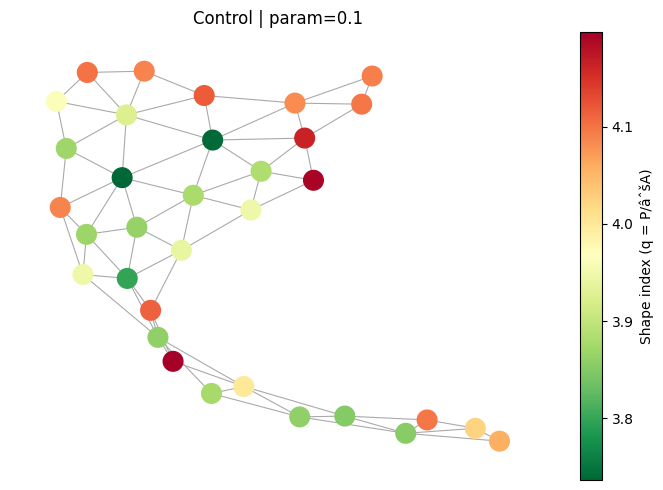

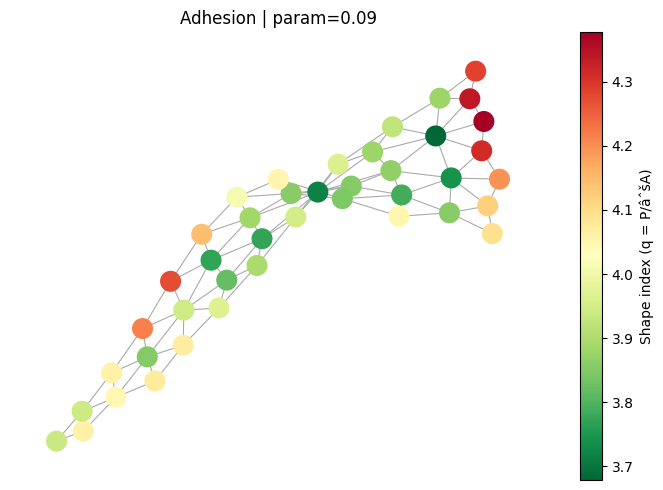

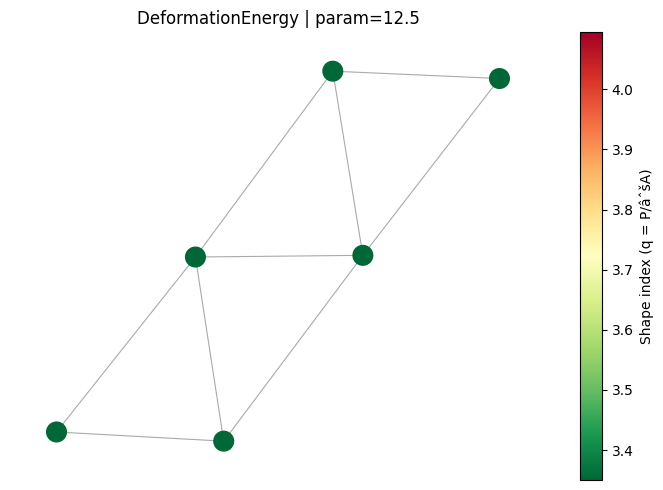

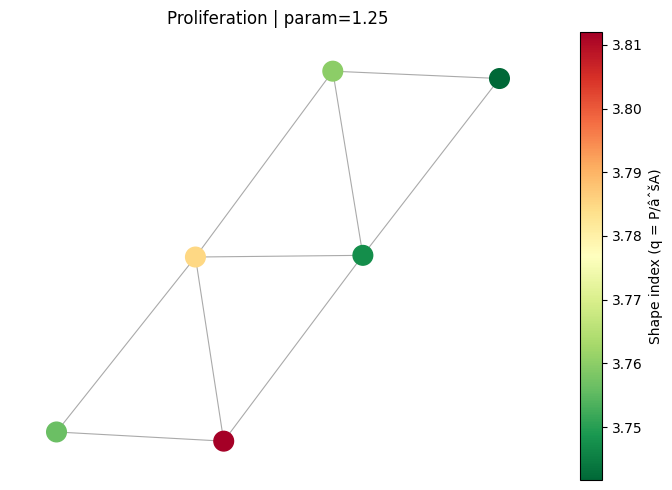

In [8]:
# Visualise one graph (networkx layout) 
def plot_cell_graph(graph: Data, title='Cell graph'):
    G = nx.Graph()
    G.add_nodes_from(range(graph.num_nodes))
    ei = graph.edge_index.numpy()
    for s, d in zip(ei[0], ei[1]):
        if s < d:
            G.add_edge(int(s), int(d))

    shape_idx = graph.x[:, 2].numpy()
    node_colors = plt.cm.RdYlGn_r((shape_idx - shape_idx.min()) /
                                   (shape_idx.max() - shape_idx.min() + 1e-9))

    fig, ax = plt.subplots(figsize=(7, 5))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, ax=ax, node_color=node_colors, node_size=200,
            edge_color='#aaa', width=0.8, with_labels=False)
    sm = plt.cm.ScalarMappable(cmap='RdYlGn_r',
                                norm=plt.Normalize(shape_idx.min(), shape_idx.max()))
    plt.colorbar(sm, ax=ax, label='Shape index (q = P/âˆšA)')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# Show one graph from each suite
for suite_name in ['Control','Adhesion','DeformationEnergy','Proliferation']:
    idxs = [i for i, g in enumerate(all_graphs) if g.suite == suite_name]
    if idxs:
        g_ex = all_graphs[idxs[len(idxs)//2]]
        plot_cell_graph(g_ex, title=f'{suite_name} | param={g_ex.param_value}')

Examples above provide random snapshots of what the graphical metric looks like (will be utilized for downstream training).

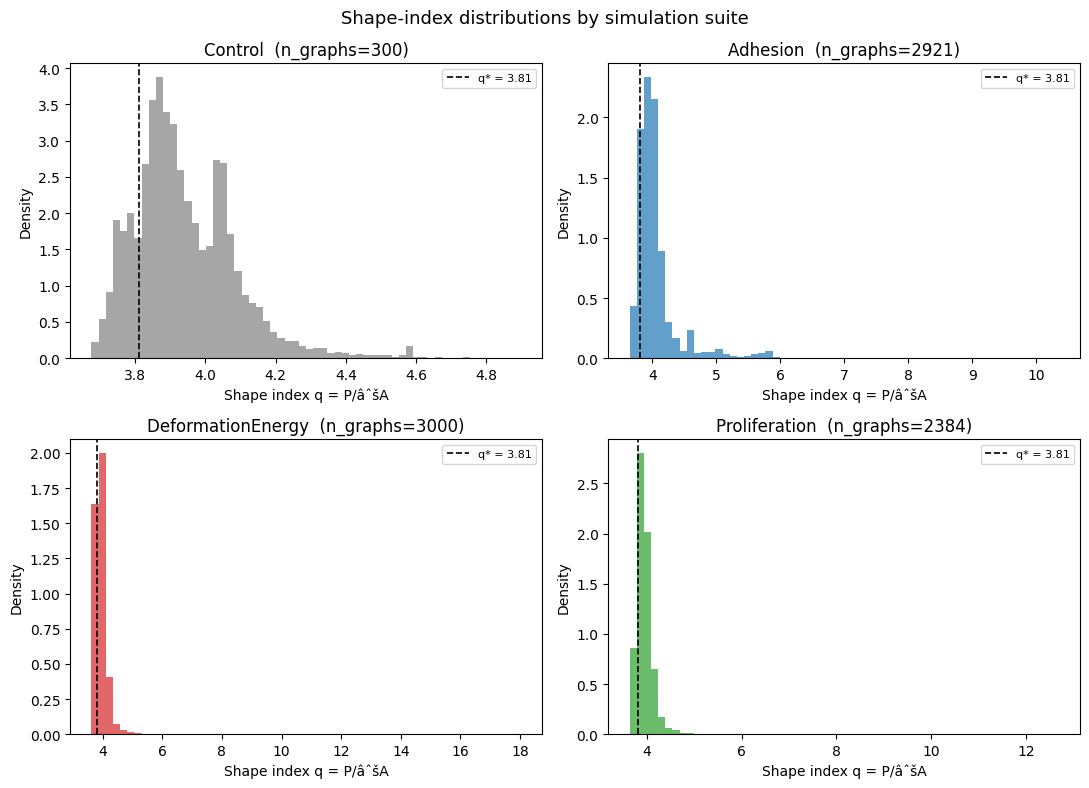

Saved shape_index_distributions.png


In [9]:
# Shape index distribution per suite 
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
suite_colors = {'Control': 'gray', 'Adhesion': '#1f77b4',
                'DeformationEnergy': '#d62728', 'Proliferation': '#2ca02c'}

for ax, (suite_name, color) in zip(axes.flat, suite_colors.items()):
    idxs = [i for i, g in enumerate(all_graphs) if g.suite == suite_name]
    if not idxs:
        ax.set_visible(False)
        continue
    # Pool shape indices from all snapshots of this suite
    all_si = np.concatenate([all_graphs[i].x[:, 2].numpy() for i in idxs])
    ax.hist(all_si, bins=60, color=color, alpha=0.7, density=True)
    ax.axvline(3.81, color='k', linestyle='--', linewidth=1.2, label='q* = 3.81')
    ax.set_xlabel('Shape index q = P/âˆšA')
    ax.set_ylabel('Density')
    ax.set_title(f'{suite_name}  (n_graphs={len(idxs)})')
    ax.legend(fontsize=8)

plt.suptitle('Shape-index distributions by simulation suite', fontsize=13)
plt.tight_layout()
plt.savefig(BANK / 'shape_index_distributions.png', dpi=150)
plt.show()
print('Saved shape_index_distributions.png')

Note: will consider changing the shape-index to be 3.81 potentially to reflect the literature better.

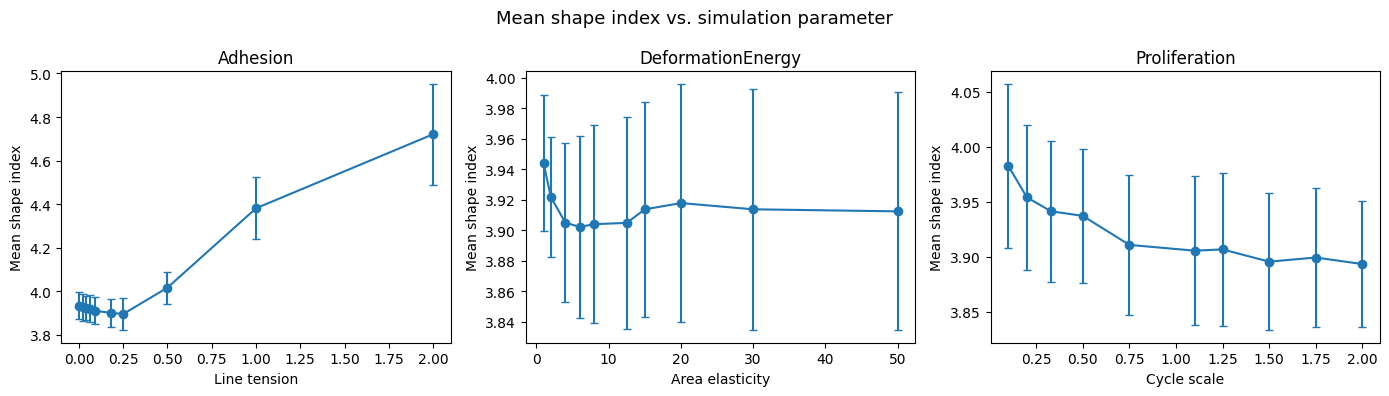

Saved shape_index_vs_param.png


In [10]:
# Mean shape index vs parameter value (per suite) 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
suite_param = {
    'Adhesion':          ('line_tension',    'Line tension'),
    'DeformationEnergy': ('area_elasticity', 'Area elasticity'),
    'Proliferation':     ('cycle_scale',     'Cycle scale'),
}

for ax, (suite_name, (pname, plabel)) in zip(axes, suite_param.items()):
    sub = df[df['suite'] == suite_name].groupby('param_value')['mean_shape_index'].agg(['mean','std'])
    ax.errorbar(sub.index, sub['mean'], yerr=sub['std'], fmt='o-', capsize=3)
    ax.set_xlabel(plabel)
    ax.set_ylabel('Mean shape index')
    ax.set_title(suite_name)

plt.suptitle('Mean shape index vs. simulation parameter', fontsize=13)
plt.tight_layout()
plt.savefig(BANK / 'shape_index_vs_param.png', dpi=150)
plt.show()
print('Saved shape_index_vs_param.png')

## 7. Feature normalization

In [11]:
# Compute normalization statistics from TRAINING graphs only 
train_graphs = [g for g in all_graphs if g.split == 'train']
val_graphs   = [g for g in all_graphs if g.split == 'val']
test_graphs  = [g for g in all_graphs if g.split == 'test']

print(f'Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}')

# Stack all node features from training set
all_x_train = torch.cat([g.x for g in train_graphs], dim=0)   # (total_nodes, 4)
feat_mean = all_x_train.mean(dim=0)
feat_std  = all_x_train.std(dim=0).clamp(min=1e-6)

feat_names = ['area', 'perimeter', 'shape_index', 'n_neighbors']
for nm, mu, sd in zip(feat_names, feat_mean.tolist(), feat_std.tolist()):
    print(f'  {nm:16s}  mean={mu:.4f}  std={sd:.4f}')

# Save stats
torch.save({'mean': feat_mean, 'std': feat_std},
           BANK / 'node_feature_stats.pt')
print('\nSaved node_feature_stats.pt')

Train: 5984 | Val: 1737 | Test: 884
  area              mean=0.5445  std=0.2680
  perimeter         mean=2.7762  std=0.8227
  shape_index       mean=3.9466  std=0.2079
  n_neighbors       mean=4.7990  std=1.5461

Saved node_feature_stats.pt


In [12]:
# Apply z-score normalization to all graphs 
def normalize_graph(g: Data, mean: torch.Tensor, std: torch.Tensor) -> Data:
    g = g.clone()
    g.x = (g.x - mean) / std
    return g

train_norm = [normalize_graph(g, feat_mean, feat_std) for g in train_graphs]
val_norm   = [normalize_graph(g, feat_mean, feat_std) for g in val_graphs]
test_norm  = [normalize_graph(g, feat_mean, feat_std) for g in test_graphs]

print(f'Normalized {len(train_norm)+len(val_norm)+len(test_norm)} graphs.')

Normalized 8605 graphs.


## 8. Train / Val / Test split summary

In [13]:
# Summary table 
split_summary = pd.DataFrame([
    {'Split': 'Train', 'Graphs': len(train_norm),
     'Nodes (total)': sum(g.num_nodes for g in train_norm),
     'Edges (undirected)': sum(g.num_edges//2 for g in train_norm)},
    {'Split': 'Val',   'Graphs': len(val_norm),
     'Nodes (total)': sum(g.num_nodes for g in val_norm),
     'Edges (undirected)': sum(g.num_edges//2 for g in val_norm)},
    {'Split': 'Test',  'Graphs': len(test_norm),
     'Nodes (total)': sum(g.num_nodes for g in test_norm),
     'Edges (undirected)': sum(g.num_edges//2 for g in test_norm)},
])
print(split_summary.to_string(index=False))

print('\nSimulation variants in each split:')
for split_name in ['train','val','test']:
    sg = [g for g in all_graphs if g.split == split_name]
    variants = set((g.suite, g.param_value) for g in sg)
    print(f'  {split_name}: {len(variants)} variants â€” {sorted(variants)}')

Split  Graphs  Nodes (total)  Edges (undirected)
Train    5984         329681              791075
  Val    1737          60073              116810
 Test     884          28716               49473

Simulation variants in each split:
  train: 22 variants â€” [('Adhesion', 0.0), ('Adhesion', 0.02), ('Adhesion', 0.04), ('Adhesion', 0.06), ('Adhesion', 0.09), ('Adhesion', 0.18), ('Adhesion', 0.25), ('Control', 0.1), ('DeformationEnergy', 1.0), ('DeformationEnergy', 2.0), ('DeformationEnergy', 4.0), ('DeformationEnergy', 6.0), ('DeformationEnergy', 8.0), ('DeformationEnergy', 12.5), ('DeformationEnergy', 15.0), ('Proliferation', 0.1), ('Proliferation', 0.2), ('Proliferation', 0.33), ('Proliferation', 0.5), ('Proliferation', 0.75), ('Proliferation', 1.1), ('Proliferation', 1.25)]
  val: 6 variants â€” [('Adhesion', 0.5), ('Adhesion', 1.0), ('DeformationEnergy', 20.0), ('DeformationEnergy', 30.0), ('Proliferation', 1.5), ('Proliferation', 1.75)]
  test: 3 variants â€” [('Adhesion', 2.0), ('Def

## 9. PyTorch Geometric DataLoaders

In [14]:
BATCH_SIZE = 32

train_loader = DataLoader(train_norm, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_norm,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_norm,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train loader: {len(train_loader)} batches of up to {BATCH_SIZE} graphs')
print(f'Val loader  : {len(val_loader)} batches')
print(f'Test loader : {len(test_loader)} batches')

# Inspect one batch
batch = next(iter(train_loader))
print(f'\nSample batch:')
print(f'  x         : {batch.x.shape}       # (total_nodes_in_batch, 4)')
print(f'  edge_index: {batch.edge_index.shape}  # (2, total_edges_in_batch)')
print(f'  edge_attr : {batch.edge_attr.shape}')
print(f'  y         : {batch.y.shape}   # (batch_size*2,) - reshape with .view(-1,2) -> [sim_type, param_value]')
print(f'  batch vec : {batch.batch.shape}   # maps each node to its graph index')

Train loader: 187 batches of up to 32 graphs
Val loader  : 55 batches
Test loader : 28 batches

Sample batch:
  x         : torch.Size([1333, 4])       # (total_nodes_in_batch, 4)
  edge_index: torch.Size([2, 6230])  # (2, total_edges_in_batch)
  edge_attr : torch.Size([6230, 1])
  y         : torch.Size([64])   # (batch_size*2,) - reshape with .view(-1,2) -> [sim_type, param_value]
  batch vec : torch.Size([1333])   # maps each node to its graph index


## 10. Save processed dataset to BIOE242 Data Bank

In [15]:
# Save graph lists 
torch.save(train_norm, BANK / 'train_graphs.pt')
torch.save(val_norm,   BANK / 'val_graphs.pt')
torch.save(test_norm,  BANK / 'test_graphs.pt')

# Also save raw (un-normalized) for inspection / alternative normalization
torch.save(train_graphs, BANK / 'train_graphs_raw.pt')
torch.save(val_graphs,   BANK / 'val_graphs_raw.pt')
torch.save(test_graphs,  BANK / 'test_graphs_raw.pt')

# Save metadata dataframe
df.to_csv(BANK / 'dataset_metadata.csv', index=False)

print(f'Saved to {BANK}/')
print('  train_graphs.pt          (normalized)')
print('  val_graphs.pt            (normalized)')
print('  test_graphs.pt           (normalized)')
print('  train/val/test_graphs_raw.pt')
print('  node_feature_stats.pt    (mean/std from train set)')
print('  dataset_metadata.csv     (per-snapshot stats)')
print('  shape_index_distributions.png')
print('  shape_index_vs_param.png')

Saved to c:\Users\cmchu\OneDrive\Desktop\Gu Lab\BIOE242 Data\BIOE242 Data Bank Complete/
  train_graphs.pt          (normalized)
  val_graphs.pt            (normalized)
  test_graphs.pt           (normalized)
  train/val/test_graphs_raw.pt
  node_feature_stats.pt    (mean/std from train set)
  dataset_metadata.csv     (per-snapshot stats)
  shape_index_distributions.png
  shape_index_vs_param.png


In [16]:
# Verify reload works 
train_check = torch.load(BANK / 'train_graphs.pt', weights_only=False)
print(f'Reloaded {len(train_check)} training graphs from disk.')
print(f'First graph: {train_check[0]}')

Reloaded 5984 training graphs from disk.
First graph: Data(x=[6, 4], edge_index=[2, 18], edge_attr=[18, 1], y=[2], num_nodes=6, suite='Control', split='train', param_name='motility', param_value=0.1, snapshot='c:\Users\cmchu\OneDrive\Desktop\Gu Lab\BIOE242 Data\replicated_testoutput\EpithelialRheology\Control_15x4\rep1\results_from_time_0\results_0.vtu')


## 11. Usage guide for downstream GNN training

```python
import torch
from torch_geometric.loader import DataLoader
from pathlib import Path

BANK = Path('BIOE242 Data Bank')

# Load pre-processed splits
train_graphs = torch.load(BANK / 'train_graphs.pt', weights_only=False)
val_graphs   = torch.load(BANK / 'val_graphs.pt',   weights_only=False)
test_graphs  = torch.load(BANK / 'test_graphs.pt',  weights_only=False)

# Reload normalization stats (to normalize new/test data consistently)
stats = torch.load(BANK / 'node_feature_stats.pt', weights_only=True)
feat_mean, feat_std = stats['mean'], stats['std']

# DataLoaders
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=32)
test_loader  = DataLoader(test_graphs,  batch_size=32)

# Each batch.y has shape (B, 2)
# y = batch.y.view(-1, 2)
# y[:, 0]  -> sim_type (0=Control, 1=Adhesion, 2=Deform, 3=Prolif)
# # y[:, 1]  -> raw parameter value (line_tension / area_elasticity / cycle_scale)
```

### Node features
| Index | Feature | Notes |
|-------|---------|-------|
| 0 | Area | Cell volume from Chaste |
| 1 | Perimeter | Sum of shared-edge lengths |
| 2 | Shape index q = P/sqrt(A) | ~3.81 at jamming transition |
| 3 | n_neighbors | Cell degree in contact network |

### Edge features
| Index | Feature |
|-------|--------|
| 0 | Shared interface length |

## 12. Additional Consideration

Given the circumstance seen in section 5.1 regarding class imbalance and temporal autocorrelation, I intend on producing some more data so that there is more to reference. I currently run only one "replicate" of each simulation seen above - my simulations can alter the seed and incorporate biological variability. Due to time constraints, I am not able to have all of this data for the data preparation. However, the data will look very similar (there won't be stark contrasts between replicates that warrant concern) and the outputs seen here will be very similar with the main exception being how much data we have. I will be running triplicates for all the conditions seen above (effectively tripling the amount of data we can train, validate, and test on) over the weekend and will have this prepared. The next Project Checkpoint will not be impacted by this. 